# 01 — The comparison arm, and an arrow that points either way

*Confirmed results C11–C14 (ledger entry B5).*

Companion to `bitacora/03_comparison_arm.md`.

In [1]:
"""Path setup: makes the notebook runnable from anywhere."""
import os, sys, json, warnings
warnings.filterwarnings("ignore")

here = os.path.abspath(os.getcwd())
while here != "/" and not os.path.exists(os.path.join(here, "PROTOCOL_causal_timeseries.md")):
    here = os.path.dirname(here)
if here == "/":
    here = os.path.expanduser("~/Documents/projects/CausalBool/imp-prices")
ROOT = here
sys.path.insert(0, os.path.join(ROOT, "src"))
sys.path.insert(0, os.path.join(ROOT, "scripts"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})
print("root:", ROOT)
print("numpy", np.__version__, "| pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

root: /Users/alberto/Documents/projects/CausalBool/imp-prices
numpy 2.2.6 | pandas 2.3.3 | matplotlib 3.11.1


## 1. What this notebook establishes

The index-set network is to be measured against a belief network, so the belief
network has to be *ours* first. This notebook does two things:

1. **Parity of the comparison arm (C11).** Every quantity that determines an
   outcome reproduces the GWP3 record: all eighteen configurations of both
   specifications, the selected models, the blankets, every score, the benchmarks
   and the inferential statistics.
2. **Stability (C12–C14), which is ledger entry B5.** GWP3 section 7 judges the
   dissertation's policy-relevance claim *"partially achieved; the framework is
   appropriate, the evidential standard is not"*, citing an edge count ranging
   from 2 to 25 and the absence of any stability analysis. We supply one, and the
   answer is worse than the report supposed: **the selected causal graph's arrow
   directions are decided by the interpreter's string hashing.**

Fitting thirty-six belief networks takes a few minutes.

### 2. The two specifications

In [2]:
from imp_prices import load_and_split, RegimeDiscretiser, SERIES, TARGET
from imp_prices.belief_network import (frame_A, frame_B, tune_on_validation,
                                       predict_regimes, score_forecast,
                                       benchmarks, accuracy_ci, mcnemar)
from imp_prices.config import GWP3_RESULTS

reference = json.load(open(GWP3_RESULTS))
split = load_and_split()

frames = {}
for kind in ("parity", "gaussian"):
    fr = RegimeDiscretiser(kind).fit(split.train).transform(split.full)
    frames[kind] = {n: fr.reindex(p.index).dropna().astype(int) for n, p in
                    [("train", split.train), ("val", split.val), ("test", split.test)]}

A = {k: frame_A(frames["parity"][k]) for k in ("train", "val", "test")}
B = {k: frame_B(frames["gaussian"][k]) for k in ("train", "val", "test")}

print("A (replication): parity emissions; 'forecast' DUPLICATES the current regime")
print("   -> the search learns a deterministic identity; rolling it forward one")
print("      month turns an exact nowcast into a measure of regime persistence,")
print("      and parity persistence is zero by construction.")
print("B (improved)   : log-return emissions; 'forecast' is the regime one month AHEAD")
print("\nframe shapes:", {k: v.shape for k, v in B.items()})

Model is not converging.  Current: 133.6292135815284 is not greater than 133.64611090460522. Delta is -0.016897323076818793


Model is not converging.  Current: 135.12412379396633 is not greater than 135.13466135759776. Delta is -0.010537563631430658


Model is not converging.  Current: 137.95241214051376 is not greater than 137.9719991672316. Delta is -0.019587026717829303


Model is not converging.  Current: 133.8785930254865 is not greater than 133.88411470889034. Delta is -0.0055216834038276374


Model is not converging.  Current: 137.8805787609427 is not greater than 137.88701219673231. Delta is -0.0064334357896029815


...

Model is not converging.  Current: 134.6463798744827 is not greater than 134.6661180024403. Delta is -0.019738127957594997


Model is not converging.  Current: 138.689566784798 is not greater than 138.75651219277114. Delta is -0.06694540797315085


Model is not converging.  Current: 137.73058048980627 is not greater than 137.74346014343874. Delta is -0.012879653632467125


Model is not converging.  Current: 137.0533835102066 is not greater than 137.05519354805233. Delta is -0.0018100378457290844


A (replication): parity emissions; 'forecast' DUPLICATES the current regime
   -> the search learns a deterministic identity; rolling it forward one
      month turns an exact nowcast into a measure of regime persistence,
      and parity persistence is zero by construction.
B (improved)   : log-return emissions; 'forecast' is the regime one month AHEAD

frame shapes: {'train': (137, 8), 'val': (29, 8), 'test': (29, 8)}


In [3]:
gridA = tune_on_validation(A["train"], A["val"], "forecast", shift=True)
gridB = tune_on_validation(B["train"], B["val"], "forecast", shift=False)
strip = lambda g: [{k: v for k, v in r.items() if k != "model"} for r in g]
cfg = lambda r: f"{r['scoring']}/{r['max_indegree']}/{r['expert_seeded']}"

for spec, grid in (("A", gridA), ("B", gridB)):
    ours = {cfg(r): r for r in strip(grid)}
    theirs = {cfg(r): r for r in reference[f"validation_grid_{spec}"]}
    acc_ok = all(ours[k]["val_accuracy"] == theirs[k]["val_accuracy"] for k in theirs)
    err_ok = all(ours[k]["val_error"] == theirs[k]["val_error"] for k in theirs)
    diff = {k for k in theirs if ours[k]["n_edges"] != theirs[k]["n_edges"]}
    print(f"spec {spec}: 18 configs | val_accuracy identical {acc_ok} | val_error identical {err_ok}")
    print(f"         n_edges differs on {len(diff)} configs: {sorted(diff)}")
print("\nselected A:", strip(gridA)[0])
print("selected B:", strip(gridB)[0])
print("matches record:", strip(gridA)[0] == reference["selected_A"],
      strip(gridB)[0] == reference["selected_B"])

spec A: 18 configs | val_accuracy identical True | val_error identical True
         n_edges differs on 0 configs: []
spec B: 18 configs | val_accuracy identical True | val_error identical True
         n_edges differs on 3 configs: ['bdeu/2/True', 'bdeu/3/True', 'bdeu/None/True']

selected A: {'scoring': 'k2', 'max_indegree': None, 'expert_seeded': True, 'n_edges': 24, 'val_accuracy': 13.33, 'val_error': 86.67}
selected B: {'scoring': 'bic-d', 'max_indegree': 2, 'expert_seeded': False, 'n_edges': 4, 'val_accuracy': 58.62, 'val_error': 41.38}
matches record: True True


The edge-count disagreement is confined to the BDeu score and is off by exactly
one edge. It is not a porting error — section 4 shows what it is.

### 3. Scores, benchmarks and inference against the record (C11, anchors A8–A12)

In [4]:
modelA, modelB = gridA[0]["model"], gridB[0]["model"]
rows = []
for spec, model, frame, shift in (("A", modelA, A, True), ("B", modelB, B, False)):
    for w, key in (("val", "validation"), ("test", "test")):
        s = score_forecast(frame[w]["forecast"].values,
                           predict_regimes(model, frame[w]), shift=shift)
        assert s == reference[f"model{spec}"][key], (spec, key)
        rows.append(dict(model=spec, window=key, accuracy=s["accuracy"],
                         balanced_accuracy=s["balanced_accuracy"], macro_f1=s["macro_f1"],
                         n=s["n"]))
display(pd.DataFrame(rows))

y = B["test"]["forecast"].values
bench = benchmarks(y, B["train"]["forecast"].values, B["test"][TARGET].values)
n = len(y)
sB = score_forecast(y, predict_regimes(modelB, B["test"]))
print("benchmarks (test):", {k: v for k, v in bench.items() if k != "majority_state"})
print("improved 95% interval:", accuracy_ci(round(sB["accuracy"] / 100 * n), n))
print("McNemar vs persistence:", mcnemar(y, sB["y_pred"], B["test"][TARGET].values))
print("McNemar vs majority   :", mcnemar(y, sB["y_pred"], np.full(n, bench["majority_state"])))
print("\nall identical to the record:",
      bench["persistence"] == reference["benchmarks_test"]["Persistence"] == 79.31)

,model,window,accuracy,balanced_accuracy,macro_f1,n
0,A,validation,13.33,17.32,13.03,30
1,A,test,23.33,22.35,19.26,30
2,B,validation,58.62,34.39,30.95,29
3,B,test,75.86,41.67,39.31,29


benchmarks (test): {'uninformed': 34.48, 'majority': 72.41, 'persistence': 79.31}
improved 95% interval: [np.float64(56.46), np.float64(89.7)]
McNemar vs persistence: {'n01': 2, 'n10': 1, 'p_value': 1.0}
McNemar vs majority   : {'n01': 0, 'n10': 1, 'p_value': 1.0}

all identical to the record: True


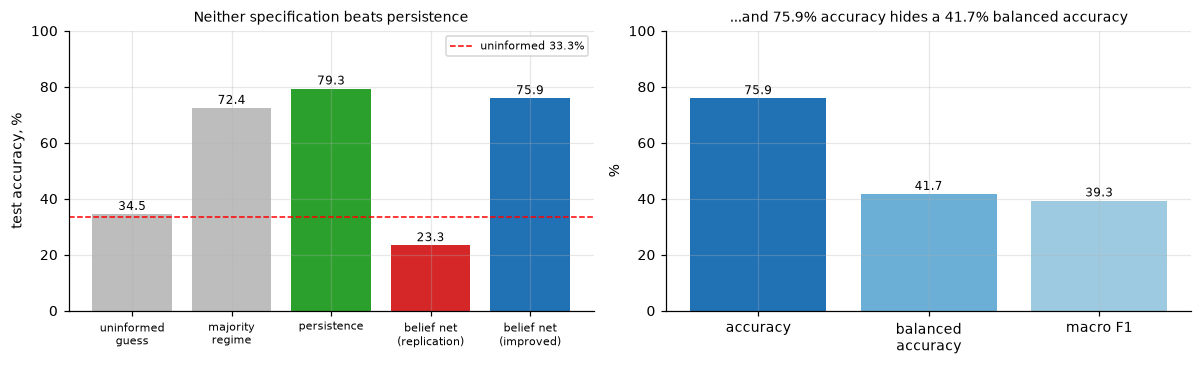

Anchor A13: the improved model answers 'stagnant' in 26 of 29 months.
confusion (rows = realised, cols = forecast):


,Bear,Stagnant,Bull
Bear,1,3,0
Stagnant,0,21,0
Bull,2,2,0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
names = ["uninformed\nguess", "majority\nregime", "persistence", "belief net\n(replication)", "belief net\n(improved)"]
vals = [bench["uninformed"], bench["majority"], bench["persistence"],
        reference["modelA"]["test"]["accuracy"], sB["accuracy"]]
cols = ["#BDBDBD", "#BDBDBD", "#2CA02C", "#D62728", "#2171B5"]
axes[0].bar(names, vals, color=cols)
axes[0].axhline(100/3, ls="--", color="red", lw=1, label="uninformed 33.3%")
for i, v in enumerate(vals): axes[0].text(i, v + 1.5, f"{v:.1f}", ha="center", fontsize=8)
axes[0].set_ylabel("test accuracy, %"); axes[0].set_ylim(0, 100); axes[0].legend(fontsize=7)
axes[0].set_title("Neither specification beats persistence", fontsize=9)
axes[0].tick_params(axis="x", labelsize=7)

acc = [sB["accuracy"], sB["balanced_accuracy"], sB["macro_f1"]]
axes[1].bar(["accuracy", "balanced\naccuracy", "macro F1"], acc, color=["#2171B5", "#6BAED6", "#9ECAE1"])
for i, v in enumerate(acc): axes[1].text(i, v + 1.5, f"{v:.1f}", ha="center", fontsize=8)
axes[1].set_ylim(0, 100); axes[1].set_ylabel("%")
axes[1].set_title("...and 75.9% accuracy hides a 41.7% balanced accuracy", fontsize=9)
plt.tight_layout(); plt.show()
print("Anchor A13: the improved model answers 'stagnant' in 26 of 29 months.")
print("confusion (rows = realised, cols = forecast):")
display(pd.DataFrame(sB["confusion"], index=["Bear","Stagnant","Bull"], columns=["Bear","Stagnant","Bull"]))

### 4. The instability, and how it was found (C12)

A test began flapping: specification B's grid failed one run and passed the next
with no change to the code. Five consecutive runs *in one process* were identical.
Running A before B changed nothing. Churning the global numpy generator changed
nothing.

`PYTHONHASHSEED` changed the answer. pgmpy's greedy search breaks score ties in
the iteration order of a hashed collection, and the hash seed is fixed at
interpreter start-up — so it cannot be varied from inside a process. The sweep
below re-executes a script as a subprocess for each seed.

In [6]:
import subprocess, sys
script = os.path.join(ROOT, "scripts", "phase1_stability.py")
runs = {}
for seed in range(6):
    out = subprocess.run([sys.executable, script, "--emit"],
                         env=dict(os.environ, PYTHONHASHSEED=str(seed)),
                         capture_output=True, text=True)
    line = [l for l in out.stdout.splitlines() if l.startswith("@@GRID@@")]
    assert line, out.stderr[-1500:]
    runs[seed] = json.loads(line[0][len("@@GRID@@"):])
    print(f"  hash seed {seed} done", flush=True)

rows = []
for spec in ("A", "B"):
    R = {cfg(r): r for r in reference[f"validation_grid_{spec}"]}
    for seed, g in runs.items():
        O = {cfg(r): r for r in g[spec]["rows"]}
        rows.append(dict(spec=spec, hash_seed=seed,
                         acc_identical=all(O[k]["val_accuracy"] == R[k]["val_accuracy"] for k in R),
                         n_edge_mismatches=sum(O[k]["n_edges"] != R[k]["n_edges"] for k in R),
                         selected=cfg(g[spec]["rows"][0]),
                         selected_edges=tuple(map(tuple, g[spec]["selected_edges"]))))
sweep = pd.DataFrame(rows)
display(sweep.drop(columns=["selected_edges"]))
print("Validation accuracy is identical for all 18 configurations at every seed.")
print("Only edge counts move, and only under BDeu.")

  hash seed 0 done


  hash seed 1 done


  hash seed 2 done


  hash seed 3 done


  hash seed 4 done


  hash seed 5 done


,spec,hash_seed,acc_identical,n_edge_mismatches,selected
0,A,0,True,3,k2/None/True
1,A,1,True,0,k2/None/True
2,A,2,True,0,k2/None/True
3,A,3,True,0,k2/None/True
4,A,4,True,3,k2/None/True
5,A,5,True,0,k2/None/True
6,B,0,True,0,bic-d/2/False
7,B,1,True,3,bic-d/2/False
8,B,2,True,0,bic-d/2/False
9,B,3,True,3,bic-d/2/False


Validation accuracy is identical for all 18 configurations at every seed.
Only edge counts move, and only under BDeu.


### 5. The result: two Markov-equivalent graphs (C13)

Specification B's **selected configuration** is stable — BIC-d, in-degree ≤ 2,
unseeded, four edges, validation accuracy 58.62 — and its **forecast blanket** is
stable at {WTI\_CL}. Its **edge set is not**.

In [7]:
import networkx as nx
from itertools import combinations

variants = {}
for spec in ("A", "B"):
    variants[spec] = {}
    for seed, g in runs.items():
        key = tuple(map(tuple, g[spec]["selected_edges"]))
        variants[spec].setdefault(key, []).append(seed)
    print(f"spec {spec}: {len(variants[spec])} distinct selected edge set(s) over {len(runs)} seeds; "
          f"blanket(s) {set(tuple(g[spec]['selected_blanket']) for g in runs.values())}")

def vstructs(edges):
    D = nx.DiGraph(list(edges)); out = set()
    for nd in D.nodes():
        for a, b in combinations(sorted(D.predecessors(nd)), 2):
            if not (D.has_edge(a, b) or D.has_edge(b, a)):
                out.add((a, nd, b))
    return out

vs = list(variants["B"])
if len(vs) >= 2:
    g0, g1 = vs[0], vs[1]
    same_skel = {frozenset(e) for e in g0} == {frozenset(e) for e in g1}
    print(f"\nsame skeleton: {same_skel}")
    print(f"v-structures: {sorted(vstructs(g0))} vs {sorted(vstructs(g1))}")
    print(f"=> MARKOV EQUIVALENT: {same_skel and vstructs(g0) == vstructs(g1)}")
    print(f"\nreversed: {sorted(set(g0) - set(g1))}")
    print(f"      vs: {sorted(set(g1) - set(g0))}")
else:
    print("\nonly one variant appeared in this short sweep; the 20-seed record found two")

spec A: 1 distinct selected edge set(s) over 6 seeds; blanket(s) {('Brent_BZ', 'CPI', 'Fed_Funds', 'Ind_Prod', 'USD_Idx', 'WTI_CL', 'WTI_Spot')}
spec B: 2 distinct selected edge set(s) over 6 seeds; blanket(s) {('WTI_CL',)}

same skeleton: True
v-structures: [] vs []
=> MARKOV EQUIVALENT: True

reversed: [('Brent_BZ', 'WTI_CL'), ('WTI_CL', 'WTI_Spot')]
      vs: [('WTI_CL', 'Brent_BZ'), ('WTI_Spot', 'WTI_CL')]


20-seed record: spec B distinct selected edge sets = 2, blanket stable = True, configuration stable = True
                spec A distinct selected edge sets = 1 (orientation-stable)


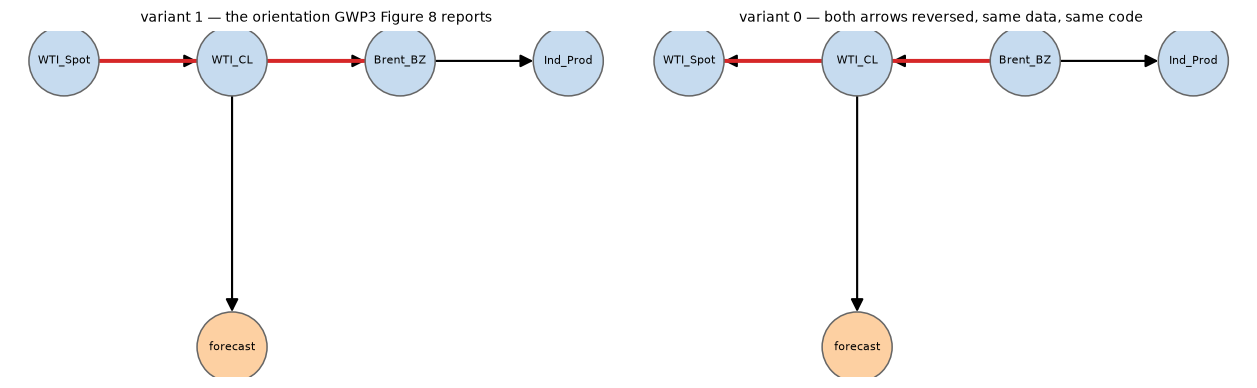

Red edges are the two that reverse. Both graphs encode identical conditional
independences, so no score built on them can tell them apart.


In [8]:
record = json.load(open(os.path.join(ROOT, "results", "phase1_stability.json")))
print(f"20-seed record: spec B distinct selected edge sets = "
      f"{record['B']['n_distinct_selected_edge_sets']}, "
      f"blanket stable = {record['B']['selected_blanket_is_stable']}, "
      f"configuration stable = {record['B']['selected_configuration_is_stable']}")
print(f"                spec A distinct selected edge sets = "
      f"{record['A']['n_distinct_selected_edge_sets']} (orientation-stable)")

# The two graphs, drawn.
G0 = [("Brent_BZ","Ind_Prod"),("Brent_BZ","WTI_CL"),("WTI_CL","WTI_Spot"),("WTI_CL","forecast")]
G1 = [("Brent_BZ","Ind_Prod"),("WTI_CL","Brent_BZ"),("WTI_Spot","WTI_CL"),("WTI_CL","forecast")]
assert {frozenset(e) for e in G0} == {frozenset(e) for e in G1}, "same skeleton"
# The drawn pair must be the pair the sweep actually found, compared as edge
# sets so that ordering cannot mask a mismatch.
found = {frozenset(v) for v in variants["B"]}
if len(found) >= 2:
    assert found == {frozenset(G0), frozenset(G1)}, f"drawn pair != observed: {found}"
pos = {"WTI_Spot": (0, 1), "WTI_CL": (1, 1), "Brent_BZ": (2, 1),
       "Ind_Prod": (3, 1), "forecast": (1, 0)}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
for ax, edges, ttl in [(axes[0], G1, "variant 1 — the orientation GWP3 Figure 8 reports"),
                       (axes[1], G0, "variant 0 — both arrows reversed, same data, same code")]:
    D = nx.DiGraph(edges)
    D.add_nodes_from(pos)
    cols = ["#FDD0A2" if nd == "forecast" else "#C6DBEF" for nd in D.nodes()]
    nx.draw_networkx(D, pos=pos, ax=ax, node_color=cols, node_size=2100,
                     font_size=7, arrowsize=17, edgecolors="0.4", width=1.4)
    flipped = [e for e in edges if e in (set(G0) ^ set(G1))]
    nx.draw_networkx_edges(D, pos=pos, ax=ax, edgelist=flipped, edge_color="#D62728",
                           width=2.6, arrowsize=20)
    ax.set_title(ttl, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()
print("Red edges are the two that reverse. Both graphs encode identical conditional")
print("independences, so no score built on them can tell them apart.")

### 6. What this establishes, and what it does not

**Established.** The predictive content of the belief network is stable and
reproduces exactly: the forecast blanket is {WTI\_CL} at every hash seed and
every score matches the record. The **causal orientation is not identified by the
data**. Two Markov-equivalent graphs occur, differing in the direction of
`Brent_BZ — WTI_CL` and `WTI_CL — WTI_Spot`, selected by a randomised
string-hashing detail with no scientific content. GWP3 section 7's criticism was
that robustness evidence was never produced; the evidence, now produced, is worse
than that criticism assumed. Sensitivity to the scoring function could be
defended as a modelling choice with a rationale. This cannot.

Note also that these arrows are exactly the ones Gate 1.0 (notebook 00) showed to
be uninformative: WTI\_CL shares the target's contemporaneous regime in 87.7 per
cent of months. The graph is asserting a causal direction between two names for
the same barrel.

**Measured since, and it went against the argument.** When this notebook was
first written, the claim that the index-set method avoids this defect was an
argument from the method's definition — functional connectivity is exact
functional dependence, checkable one input at a time, with no aggregate score to
tie — and it was labelled as an argument pending measurement in ledger entry B4.

B4 has since been measured twice (notebook 02, C15–C22) and the argument does not
survive intact. What survives is narrower than what was implied here:

- **There is no arrow to reverse in an index-set model.** The map runs from
  parents to successor by construction, so the specific pathology above — two
  Markov-equivalent graphs making opposite causal statements — cannot arise. That
  part stands.
- **Reproducibility is not stability, and on reproducibility the index-set side
  still wins outright.** The instability shown above is *same data, same
  configuration, different answer*, decided by string hashing; it has no
  statistical content. The index-set computation is deterministic to a content
  hash.
- **But the choice of parents is *less* stable, not more.** On identical
  moving-block resamples the index-set code length selects 22 distinct parent
  sets against the conditional probability table's 4 (C18). The implication drawn
  when this notebook was written — that exact functional dependence would make
  selection more stable — is false, and it survives into the corrected Phase 1b
  design, where the gate network selects a denser, more complex connectivity
  (BDM 156.45 against 123.37, 23 edges against 17) and still loses.

**Consequence.** The Phase 1 forecasting contest remains not attempted, per the
Gate 1.0 verdict. Nothing here changes that: the belief network's predictive
content is a stable {WTI\_CL} blanket, and WTI\_CL is the target under another
name.